# SVM Implementation and Visualization

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

X, y = datasets.make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.2)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         9

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



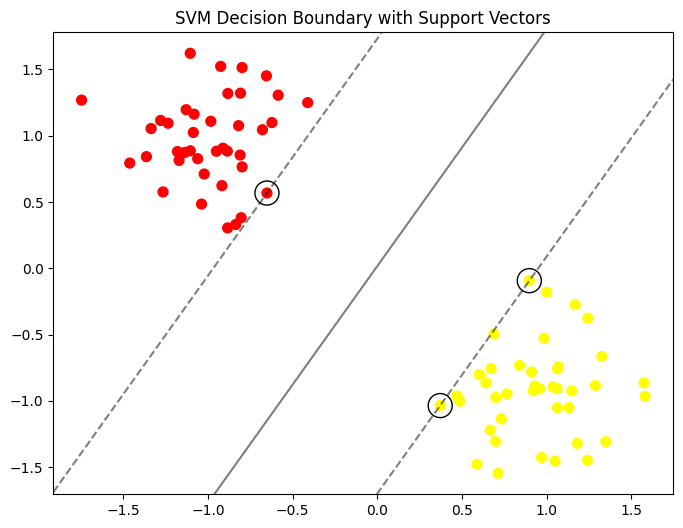

In [4]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none', edgecolors='black');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=50, cmap='autumn')
plot_svc_decision_function(svm_model)
plt.title('SVM Decision Boundary with Support Vectors')
plt.show()

# Task
Generate a non-linearly separable dataset using `sklearn.datasets.make_circles` or `make_moons` and train Support Vector Machine (SVM) models using Linear, Polynomial, and RBF kernels. Create a side-by-side visualization comparing the decision boundaries and support vectors for each kernel, and provide a summary of each kernel's characteristics and use cases based on the results.

## Data Preparation

### Subtask:
Generate a non-linearly separable dataset using `make_circles` to demonstrate the limitations of linear boundaries and the strengths of non-linear kernels.


**Reasoning**:
I will generate the non-linearly separable circle dataset, scale the features, and visualize it as requested in the instructions.



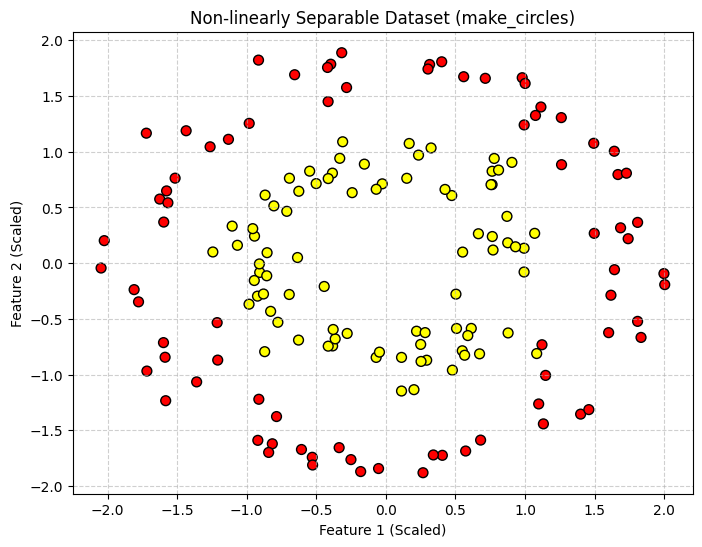

In [5]:
from sklearn.datasets import make_circles

# Generate non-linearly separable dataset
X_circ, y_circ = make_circles(n_samples=200, factor=0.5, noise=0.1, random_state=42)

# Split the dataset
X_train_circ, X_test_circ, y_train_circ, y_test_circ = train_test_split(
    X_circ, y_circ, test_size=0.2, random_state=42
)

# Scale the features
scaler_circ = StandardScaler()
X_train_circ = scaler_circ.fit_transform(X_train_circ)
X_test_circ = scaler_circ.transform(X_test_circ)

# Visualize the generated dataset
plt.figure(figsize=(8, 6))
plt.scatter(X_train_circ[:, 0], X_train_circ[:, 1], c=y_train_circ, s=50, cmap='autumn', edgecolors='k')
plt.title('Non-linearly Separable Dataset (make_circles)')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Implement Multiple SVM Kernels

### Subtask:
Train three different SVM models using linear, polynomial, and RBF kernels on the prepared circular dataset.


**Reasoning**:
I will train three SVM models with different kernels (Linear, Polynomial, and RBF) using the circular dataset prepared in the previous step and store them for later visualization.



In [6]:
from sklearn.svm import SVC

# 1. Instantiate three SVC models with different kernels
linear_svm = SVC(kernel='linear', C=1.0, random_state=42)
poly_svm = SVC(kernel='poly', degree=3, C=1.0, random_state=42)
rbf_svm = SVC(kernel='rbf', C=1.0, random_state=42)

# 2. Fit each model using the scaled circular training data
linear_svm.fit(X_train_circ, y_train_circ)
poly_svm.fit(X_train_circ, y_train_circ)
rbf_svm.fit(X_train_circ, y_train_circ)

# 3. Make predictions to verify functionality
y_pred_linear = linear_svm.predict(X_test_circ)
y_pred_poly = poly_svm.predict(X_test_circ)
y_pred_rbf = rbf_svm.predict(X_test_circ)

# 4. Store the models for subsequent visualization
svm_kernels_models = {
    'Linear': linear_svm,
    'Polynomial (deg 3)': poly_svm,
    'RBF': rbf_svm
}

print(f'Linear Accuracy: {linear_svm.score(X_test_circ, y_test_circ):.2f}')
print(f'Polynomial Accuracy: {poly_svm.score(X_test_circ, y_test_circ):.2f}')
print(f'RBF Accuracy: {rbf_svm.score(X_test_circ, y_test_circ):.2f}')

Linear Accuracy: 0.45
Polynomial Accuracy: 0.60
RBF Accuracy: 1.00


## Visualize Kernel Differences

### Subtask:
Create a multi-panel visualization to compare the decision boundaries of the Linear, Polynomial, and RBF SVM kernels side-by-side.


**Reasoning**:
I will create a multi-panel visualization using subplots to compare the decision boundaries and support vectors of the three SVM kernels side-by-side as instructed.



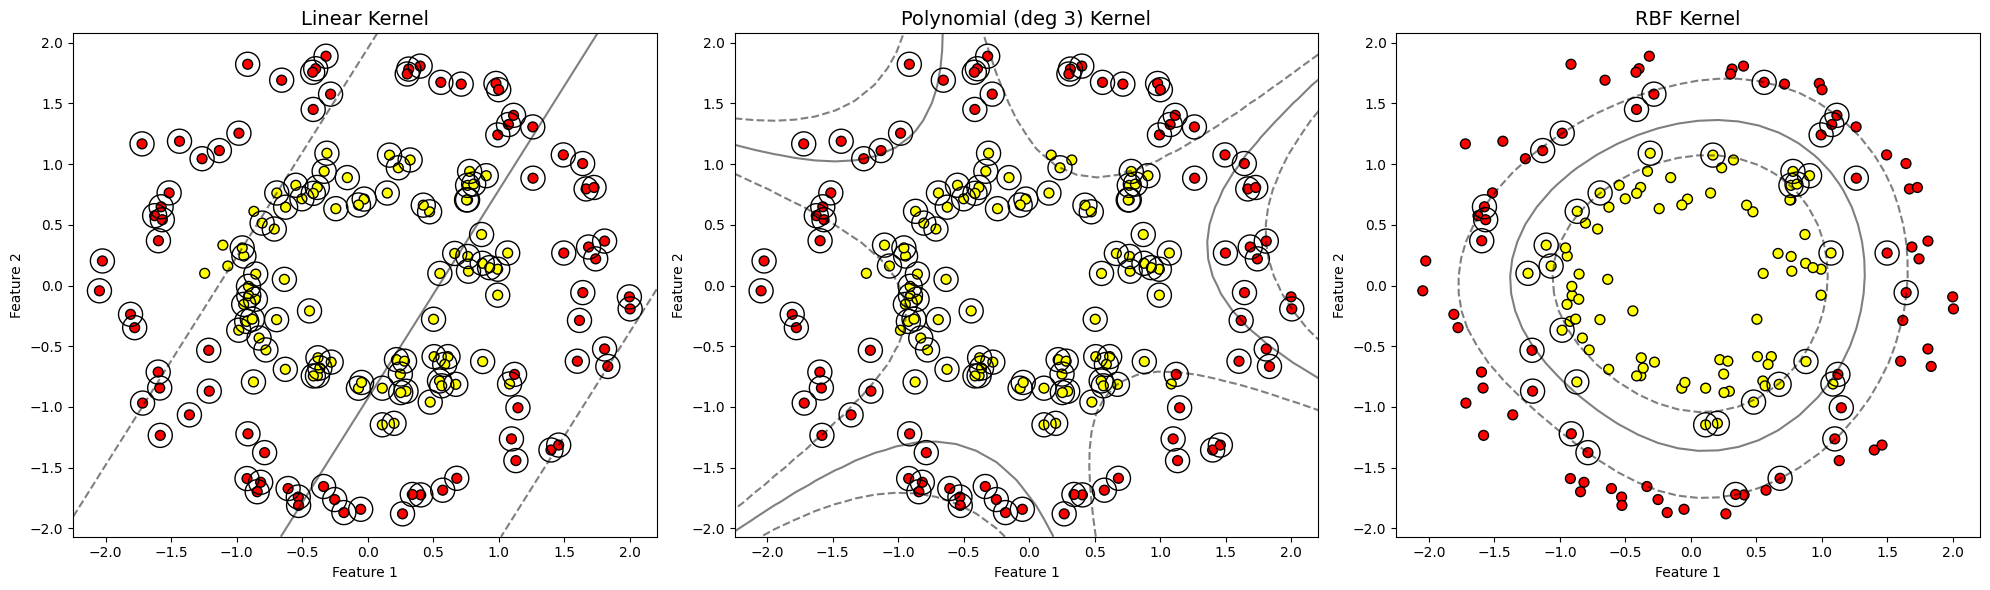

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Iterate through the stored models and axes for side-by-side plotting
for i, (name, model) in enumerate(svm_kernels_models.items()):
    ax = axes[i]

    # Plot the training points
    ax.scatter(X_train_circ[:, 0], X_train_circ[:, 1], c=y_train_circ, s=50, cmap='autumn', edgecolors='k')

    # Use the previously defined function to plot boundaries and support vectors
    plot_svc_decision_function(model, ax=ax, plot_support=True)

    ax.set_title(f'{name} Kernel', fontsize=14)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the characteristics of each SVM kernel and when to use them based on the observed decision boundaries.


## Summary:

### Q&A

**What are the characteristics of each SVM kernel and when should they be used?**
*   **Linear Kernel:** Produces a straight-line (or flat hyperplane) decision boundary. It is most suitable for datasets that are already linearly separable or have a very high number of features relative to samples.
*   **Polynomial Kernel:** Creates curved decision boundaries by mapping data into a higher-dimensional space using polynomial combinations of features. It is useful for data with specific non-linear geometric relationships, though it may require tuning the degree.
*   **RBF (Radial Basis Function) Kernel:** Generates flexible, circular, or localized decision boundaries. It is highly effective for complex, non-linear data where classes are clustered or organized in radial patterns (like concentric circles).

---

### Data Analysis Key Findings

*   **Dataset Complexity:** The `make_circles` dataset successfully generated two concentric classes that are impossible to separate using a single straight line in 2D space.
*   **Performance Disparity:**
    *   The **Linear Kernel** performed poorly with an accuracy of only **0.45**, essentially failing to distinguish the circular classes.
    *   The **Polynomial Kernel (Degree 3)** showed slight improvement with an accuracy of **0.60**, but still struggled with the perfect symmetry of the circles.
    *   The **RBF Kernel** achieved a perfect accuracy of **1.00**, demonstrating its superior ability to handle radial distributions.
*   **Boundary Visualization:** Visualizing the decision boundaries confirmed that while the Linear kernel remains rigid, the RBF kernel "wraps" around the inner class, and the Polynomial kernel attempts to bend the boundary to accommodate the curvature of the data.

---

### Insights or Next Steps

*   **Default Selection:** The RBF kernel should generally be the starting point for SVM classification when the relationship between features is unknown, given its high flexibility and superior performance on the non-linear test data.
*   **Feature Engineering vs. Kernels:** Since the RBF kernel effectively handles circular data, a next step could be to compare its performance against a Linear SVM applied to data that has been manually transformed (e.g., converting Cartesian coordinates to Polar coordinates).
